Ready to go!

First 10 customers:
   annual_spend  visits_per_month
0        1432.0               8.6
1         977.0              17.3
2         831.0              15.3
3        1451.0               8.4
4         823.0              16.4
5        1520.0               6.8
6         375.0               7.4
7         862.0              16.1
8        1648.0               8.8
9        1584.0               7.5

Customer data shape:
(180, 2)

K-Means cluster counts:
kmeans_cluster
0    61
1    59
2    60
Name: count, dtype: int64


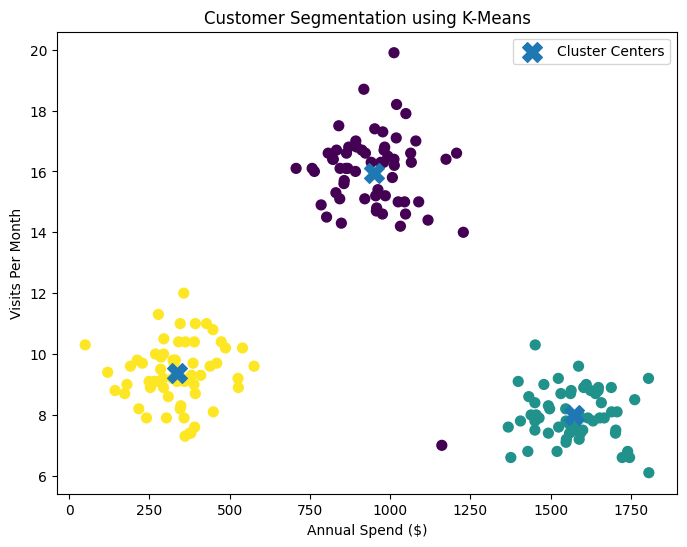


Hierarchical cluster counts:
hierarchical_cluster
0    61
1    59
2    60
Name: count, dtype: int64


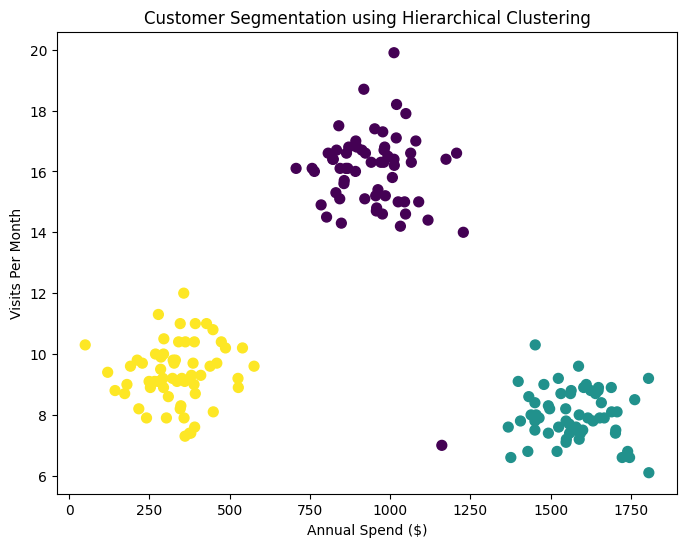

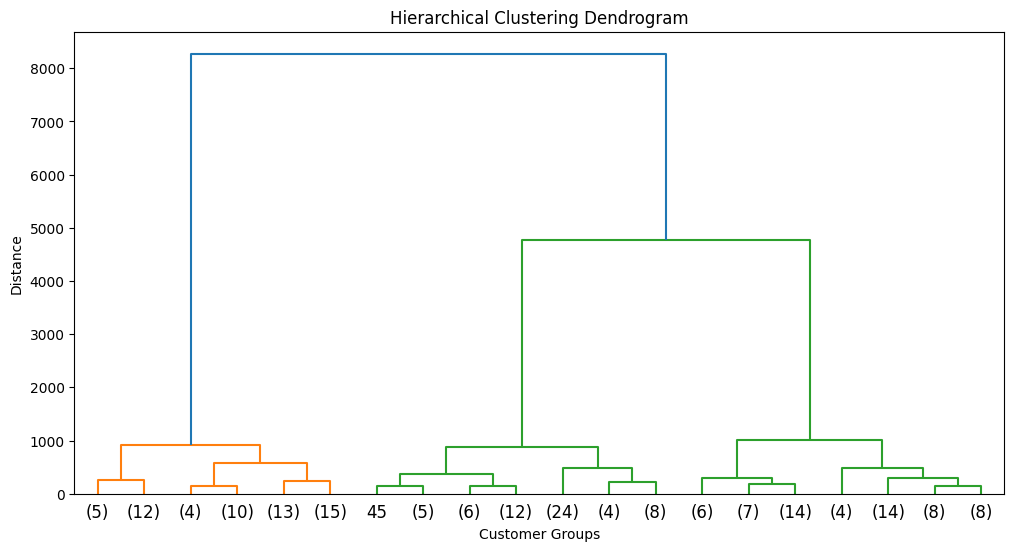


Final customer data:
   annual_spend  visits_per_month  kmeans_cluster  hierarchical_cluster
0        1432.0               8.6               1                     1
1         977.0              17.3               0                     0
2         831.0              15.3               0                     0
3        1451.0               8.4               1                     1
4         823.0              16.4               0                     0
5        1520.0               6.8               1                     1
6         375.0               7.4               2                     2
7         862.0              16.1               0                     0
8        1648.0               8.8               1                     1
9        1584.0               7.5               1                     1

Program completed successfully!


In [1]:
# numpy helps us work with numbers and arrays
import numpy as np

# pandas lets us store data in a neat table
import pandas as pd

# matplotlib is used to draw charts
import matplotlib.pyplot as plt

# make_blobs generates a simple practice dataset
from sklearn.datasets import make_blobs

# KMeans is used for K-Means clustering
from sklearn.cluster import KMeans

# AgglomerativeClustering is used for Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

# linkage and dendrogram are used to create the dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram


# --------------------------------------------------
# 1. SET RANDOM SEED
# --------------------------------------------------

np.random.seed(42)

print("Ready to go!")


# --------------------------------------------------
# 2. CREATE FAKE CUSTOMER DATA
# --------------------------------------------------

# The 3 rough centers of our fake customer groups
group_centers = [
    [-4, -2],
    [0, 3],
    [4, -3]
]

# Generate 180 customer points
raw_points, _ = make_blobs(
    n_samples=180,
    centers=group_centers,
    cluster_std=0.8,
    random_state=42
)

# Convert first raw column into annual spending
annual_spend = np.clip(
    raw_points[:, 0] * 150 + 950,
    50,
    None
).round(0)

# Convert second raw column into visits per month
visits_per_month = np.clip(
    raw_points[:, 1] * 1.3 + 12,
    1,
    None
).round(1)

# Put both features into a DataFrame
customers = pd.DataFrame({
    "annual_spend": annual_spend,
    "visits_per_month": visits_per_month
})


# --------------------------------------------------
# 3. DISPLAY CUSTOMER DATA
# --------------------------------------------------

print("\nFirst 10 customers:")
print(customers.head(10))

print("\nCustomer data shape:")
print(customers.shape)


# --------------------------------------------------
# 4. PREPARE DATA FOR CLUSTERING
# --------------------------------------------------

X = customers[
    ["annual_spend", "visits_per_month"]
]


# --------------------------------------------------
# 5. K-MEANS CLUSTERING
# --------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customers["kmeans_cluster"] = kmeans.fit_predict(X)


print("\nK-Means cluster counts:")
print(customers["kmeans_cluster"].value_counts().sort_index())


# --------------------------------------------------
# 6. DISPLAY K-MEANS CLUSTERS
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    customers["annual_spend"],
    customers["visits_per_month"],
    c=customers["kmeans_cluster"],
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Cluster Centers"
)

plt.xlabel("Annual Spend ($)")
plt.ylabel("Visits Per Month")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()


# --------------------------------------------------
# 7. HIERARCHICAL CLUSTERING
# --------------------------------------------------

hierarchical = AgglomerativeClustering(
    n_clusters=3
)

customers["hierarchical_cluster"] = hierarchical.fit_predict(X)


print("\nHierarchical cluster counts:")
print(
    customers["hierarchical_cluster"]
    .value_counts()
    .sort_index()
)


# --------------------------------------------------
# 8. DISPLAY HIERARCHICAL CLUSTERS
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    customers["annual_spend"],
    customers["visits_per_month"],
    c=customers["hierarchical_cluster"],
    s=50
)

plt.xlabel("Annual Spend ($)")
plt.ylabel("Visits Per Month")
plt.title("Customer Segmentation using Hierarchical Clustering")

plt.show()


# --------------------------------------------------
# 9. CREATE DENDROGRAM
# --------------------------------------------------

linked = linkage(
    X,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=20
)

plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()


# --------------------------------------------------
# 10. DISPLAY FINAL DATA
# --------------------------------------------------

print("\nFinal customer data:")
print(customers.head(10))

print("\nProgram completed successfully!")